In [2]:
from statistics import correlation

#数据处理和科学计算库
import numpy as np;
import pandas as pd;

#可视化库
import matplotlib.pyplot as plt;
import seaborn as sns;
from scipy.ndimage import label
from scipy.stats import alpha
from seaborn import scatterplot

#机器学习库
from sklearn.model_selection import train_test_split;
from sklearn.linear_model import LinearRegression;
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error;

#统计分析库
import statsmodels.api as sm;
from scipy import stats;
from statsmodels.graphics.tukeyplot import results
from statsmodels.sandbox.mle import data

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif']=['SimHei']; #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False; #用来正常显示负号

In [3]:
#设置随机种子保证结果可复现
np.random.seed(42);

#随机生成100个学生的学习时间
study_hours = np.random.uniform(1,10,100).reshape(-1,1);

#生成考试分数
exam_scores = 30 + study_hours * 7 + np.random.normal(0,5,100).reshape(-1,1);

data = pd.DataFrame({"study_hours":study_hours.flatten(),"exam_scores":exam_scores.flatten()});

In [4]:
print("数据前五行")
print(data.head());

数据前五行
   study_hours  exam_scores
0     4.370861    61.031263
1     9.556429    95.399965
2     7.587945    83.574422
3     6.387926    64.777640
4     2.404168    45.730815


In [5]:
study_hours

array([[4.37086107],
       [9.55642876],
       [7.58794548],
       [6.38792636],
       [2.40416776],
       [2.40395068],
       [1.52275251],
       [8.79558531],
       [6.41003511],
       [7.3726532 ],
       [1.18526045],
       [9.72918867],
       [8.49198377],
       [2.911052  ],
       [2.6364247 ],
       [2.65064059],
       [3.73818019],
       [5.72280788],
       [4.88750517],
       [3.62106226],
       [6.50667605],
       [2.25544475],
       [3.62930184],
       [4.29725659],
       [5.10462986],
       [8.06658365],
       [2.79706404],
       [5.62810995],
       [6.33173112],
       [1.41805371],
       [6.46790367],
       [2.53471711],
       [1.58546434],
       [9.53996984],
       [9.6906883 ],
       [8.27557613],
       [3.74152392],
       [1.87904903],
       [7.15809724],
       [4.96137244],
       [2.09834411],
       [5.45659219],
       [1.30949669],
       [9.18388362],
       [3.32901983],
       [6.96270056],
       [3.80539968],
       [5.680

In [6]:
exam_scores

array([[ 61.03126283],
       [ 95.39996455],
       [ 83.57442222],
       [ 64.77763993],
       [ 45.73081491],
       [ 48.61321764],
       [ 48.04873779],
       [ 88.97774609],
       [ 70.82777773],
       [ 79.09978718],
       [ 42.87383373],
       [ 99.74807623],
       [ 86.79508535],
       [ 52.94370114],
       [ 48.94036068],
       [ 53.39770907],
       [ 52.65699584],
       [ 68.42134446],
       [ 62.25199541],
       [ 48.02986109],
       [ 77.02733375],
       [ 47.09338958],
       [ 55.43068014],
       [ 58.90786046],
       [ 58.6555553 ],
       [ 84.36285895],
       [ 47.86587569],
       [ 65.38538327],
       [ 73.51568928],
       [ 41.94663029],
       [ 84.70625518],
       [ 48.61590886],
       [ 42.38600231],
       [ 96.40755927],
       [ 88.24096201],
       [ 87.79646355],
       [ 56.49181851],
       [ 55.46955374],
       [ 79.14487585],
       [ 66.23734382],
       [ 44.51484995],
       [ 62.35275515],
       [ 44.8805909 ],
       [ 98

In [7]:
data

,study_hours,exam_scores
0,4.370861,61.031263
1,9.556429,95.399965
2,7.587945,83.574422
3,6.387926,64.777640
4,2.404168,45.730815
...,...,...
95,5.444160,64.030071
96,5.704595,69.546660
97,4.847869,65.640844
98,1.228772,39.984859


In [10]:
print("数据基本统计信息： \n");
print(data.describe());

数据基本统计信息： 

       study_hours  exam_scores
count   100.000000   100.000000
mean      5.231627    66.615985
std       2.677405    18.613373
min       1.049699    35.252198
25%       2.738807    51.021252
50%       5.177282    64.403856
75%       7.571828    83.145015
max       9.881982   103.082991


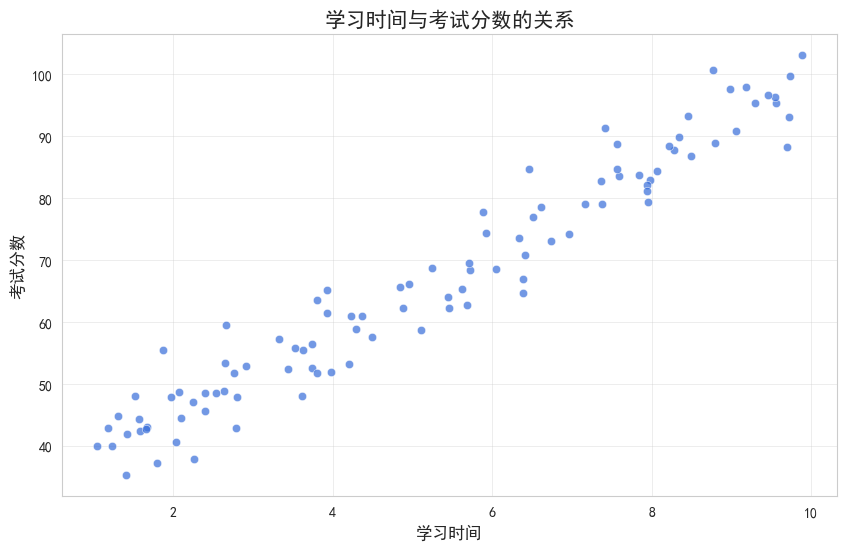

In [12]:
##数据可视化
plt.figure(figsize=(10,6)); #创建画布
sns.scatterplot(x = "study_hours",y = "exam_scores",data = data,alpha = 0.7); #绘制散点图
plt.title("学习时间与考试分数的关系",fontsize = 15);
plt.xlabel("学习时间",fontsize = 12);
plt.ylabel("考试分数",fontsize = 12);

plt.show();

In [14]:
#计算相关系数
correlation = data["study_hours"].corr(data["exam_scores"]);
print(f"相关系数为：{correlation:.4f}");

相关系数为：0.9702


In [20]:
X = data[["exam_scores"]];
y = data[["study_hours"]];

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state=42);

print(f"训练集大小：{X_train.shape[0]}");
print(f"测试集大小：{X_test.shape[0]}");

训练集大小：70
测试集大小：30


In [21]:
X_train

,exam_scores
11,99.748076
47,62.755030
85,61.421972
28,73.515689
93,68.591783
...,...
60,57.570403
71,42.916805
14,48.940361
92,83.702517


In [22]:
X_test

,exam_scores
83,44.286944
53,90.856745
70,79.466667
45,74.191967
44,57.258299
39,66.237344
22,55.430680
80,100.704388
10,42.873834
0,61.031263


模型训练

In [24]:
#创建线性回归模型实例
model = LinearRegression();
#用训练数据来训练模型
model.fit(X_train,y_train);
#获取模型参数
intercept = model.intercept_;
slope = model.coef_[0];

print("模型训练完成！")
print(f"截距：{intercept.item():.4f}");
print(f"斜率{slope.item():.4f}");

print(f"线性回归方程：{intercept.item():.2f} + {slope.item():.2f} * study_hours");

模型训练完成！
截距：-3.8592
斜率0.1375
线性回归方程：-3.86 + 0.14 * study_hours


In [28]:
#在测试集上进行预测
y_pred = model.predict(X_test);
#比较
predictions_df = pd.DataFrame({"Actual":y_test.values.ravel()
                                  ,"Predicted":y_pred.flatten()});
print("比较结果为：")
print(predictions_df.head());

比较结果为：
     Actual  Predicted
0  1.572025   2.230121
1  9.053446   8.633371
2  7.950203   7.067259
3  6.962701   6.341999
4  3.329020   4.013655


In [29]:
#计算评估指标

In [32]:
r2 = r2_score(y_test,y_pred);
mse = mean_squared_error(y_test,y_pred);
rmse = np.square(mse);

In [33]:
print(f"R2:{r2:.4f}");
print(f"MSE:{mse:.4f}");
print(f"RMSE:{rmse:.4f}");


R2:0.9620
MSE:0.3448
RMSE:0.1189


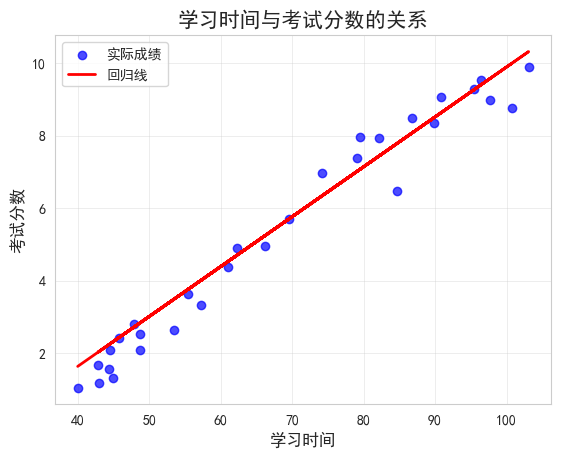

In [35]:
plt.scatter(X_test,y_test,color = "blue",label = "实际成绩",alpha = 0.7);
plt.plot(X_test,y_pred,color = "red",label = "回归线",linewidth = 2);
plt.title("学习时间与考试分数的关系",fontsize = 15);
plt.xlabel("学习时间",fontsize = 12);
plt.ylabel("考试分数",fontsize = 12);
plt.legend();
plt.show();

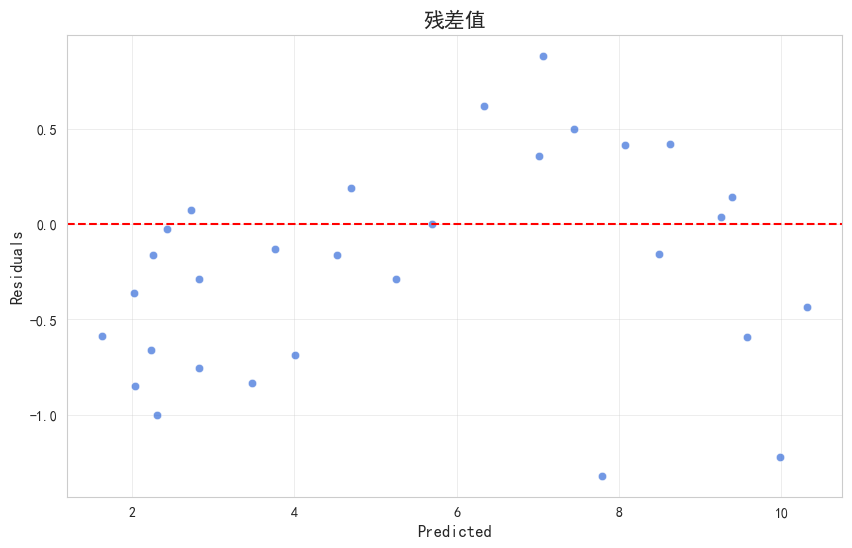

In [38]:
#计算残差
residuals = y_test - y_pred;
plt.figure(figsize=(10,6));
sns.scatterplot(x=y_pred.flatten(),y=residuals.values.ravel(),alpha = 0.7);
plt.axhline(y = 0, color = "red",linestyle = "--");
plt.title("残差值",fontsize = 15);
plt.xlabel("Predicted",fontsize = 12);
plt.ylabel("Residuals",fontsize = 12);
plt.show();

In [41]:
import warnings
# 忽略该特定警告
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [42]:
#预测
new_study_hours = np.array([[6.5]])
predicted_score = model.predict(new_study_hours);
print(predicted_score[0])

[-2.96550433]


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def run_linear_regression_analysis(data, feature_col, target_col):
    # 提取特征和目标变量
    X = data[feature_col]
    y = data[target_col]

    # ✅ 修复：单特征必须转换为 2D 数组
    X = X.values.reshape(-1, 1)

    # 划分训练集和测试集
    # 注意：你原来写反了 X_test,X_train → 正确顺序是 X_train,X_test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 模型训练
    model = LinearRegression()
    model.fit(X_train, y_train)

    # 预测与评估
    y_pred = model.predict(X_test)

    # 输出结果
    print("线性回归系数：", model.coef_[0])
    print("截距：", model.intercept_)
    print("均方误差 (MSE)：", mean_squared_error(y_test, y_pred))
    print("R² 得分：", r2_score(y_test, y_pred))



In [50]:
results = run_linear_regression_analysis(data,"study_hours","exam_scores")

线性回归系数： 6.740766099906913
截距： 30.848736710555556
均方误差 (MSE)： 15.773739044596631
R² 得分： 0.9630118664202175
